# **INTRODUCTION TO TIMESERIES**
If you attended the undergraduate session 1 of the technical skill component of this workshop you will have been introduced to categorical, ordinal and numerical data. However in most biological sciences we often want to understand how a variable changes in time. As a result, you will commmonly use a specific type of numerical data, the timeseries.

As the name implies, timeseries data demonstrates the evolution of a set of observations in time. However, this set of observations almost certainly comes from a single individual which brings up one of the most important features of timeseries. They are dependant on one another. This is both a blessing and a curse as the classical frequentist statistics that we are taught include an assumption of independence, which isn't met when all these datapoints come from the same individual. Lets take a look an an example:

Person,Height (cm)
A,168
B,175
C,162
D,181
E,170
F,177
G,165
H,172
I,169
J,183


Time (min),Heart rate (bpm)
0,70
1,82
2,124
3,155
4,120
5,127
6,154
7,123
8,131
9,92


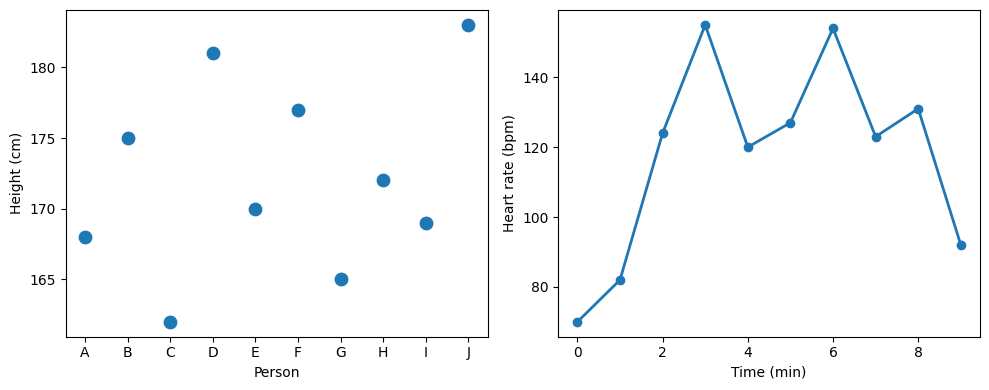

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Create some data
heights = pd.DataFrame({
    "Person": list("ABCDEFGHIJ"),
    "Height (cm)": [168, 175, 162, 181, 170, 177, 165, 172, 169, 183]
})

heart_rate = pd.DataFrame({
    "Time (min)": range(10),
    "Heart rate (bpm)": [70, 82, 124, 155, 120, 127, 154, 123, 131, 92]
})

display(heights.style.hide(axis="index"))
display(heart_rate.style.hide(axis="index"))

# Plot the data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(
    heights["Person"],
    heights["Height (cm)"],
    s=80
)
axes[0].set_xlabel("Person")
axes[0].set_ylabel("Height (cm)")

axes[1].plot(
    heart_rate["Time (min)"],
    heart_rate["Heart rate (bpm)"],
    marker="o",
    linewidth=2
)
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Heart rate (bpm)")

plt.tight_layout()
plt.show()

Now as you can see, one of these plots has time on the x-axis and is obviously a timeseries, but can you shuffle the information in either plot around on the x-axis? Why or why not?

**TO BE REMOVED: I was envisioning this as a way to introduce temporal dependence**

Timeseries data being a set of data point collected over time as a unique property whereby the ordering of observations carries important information because observations are statistically dependent on nearby observations. More intuitively, knowing the value at one time point tells us something about nearby time points. This is called temporal dependence.

In contrast, with measuring the heights of different individuals — knowing one person's height doesn't tell you much about next row in the dataset.

# **Components of a timeseries**

Because neighbouring observations are related, time series have structure that ordinary datasets do not. These structures can occur over different time scales and often contain biologically relevant information that could be of interest to our scientific inquiry.

These time-scales can range from microseconds to centuries and can be driven by a wide variety of sources.

The rest of the workshop is about learning how to recognize and separate these different forms of temporal structure.

In [3]:
import pandas as pd

timescales = pd.DataFrame({
    "Biological process": ["Ion channel opening/closing",
                           "Muscle contraction", "Heartbeat",
                           "Intracellular calcium transient",
                           "Hormone secretion (e.g. insulin)",
                           "Circadian rhythm", "Wound healing",
                           "Embryonic development", "Human growth and ageing",
                           "Tree stem growth"],
    "Approximate timescale": ["μs", "ms","~1 s","Seconds–minutes",
                              "Minutes–hours", "~24 h", "Days–weeks",
                              "Days–months", "Years–decades",
                              "Decades–centuries"]})

display(timescales.style.hide(axis="index"))

Biological process,Approximate timescale
Ion channel opening/closing,μs
Muscle contraction,ms
Heartbeat,~1 s
Intracellular calcium transient,Seconds–minutes
Hormone secretion (e.g. insulin),Minutes–hours
Circadian rhythm,~24 h
Wound healing,Days–weeks
Embryonic development,Days–months
Human growth and ageing,Years–decades
Tree stem growth,Decades–centuries


The question is how do we measure these processes?

**TO BE REMOVED: Santiagio this was a discussion to bring up instrumentation and the idea of observation = signal + noise given that many of these mechanisms aren't directly observable and even when they are they are subject to measurement error. For example, tree trunk diamater is measured a breast height diameter in an attempt to be consistent what if experimenters are different heights when meauring the same tree over its lifespan?... ask me how i know this haha**

# **How to Measure Timeseries**

Generally, we can use a wide variety of instruments to capture biological processes. These can be as simple as a tape measure for measuring a tree, a camera to track wound healing, to a set of electrode to measure one's heartbeat or an MRI scanner to capture hemodynamic responses in the brain.

Ideally, each process would perfectly capture the signal we are interested in but it it vital to remember that:

 $$Observation = Signal + Noise$$

 where

**Signal**

- biologically or physically meaningful
- systematic
- reproducible

**Noise**

- random variation
- measurement error
- stochasticity

Lets look at an example using the heart rate data from before (measured from fitbit) in it's experimental context, running a short two interval HIIT workout on trails to see the effect of different exercise intesities on heart rate:

What do you hypothesize will happen?

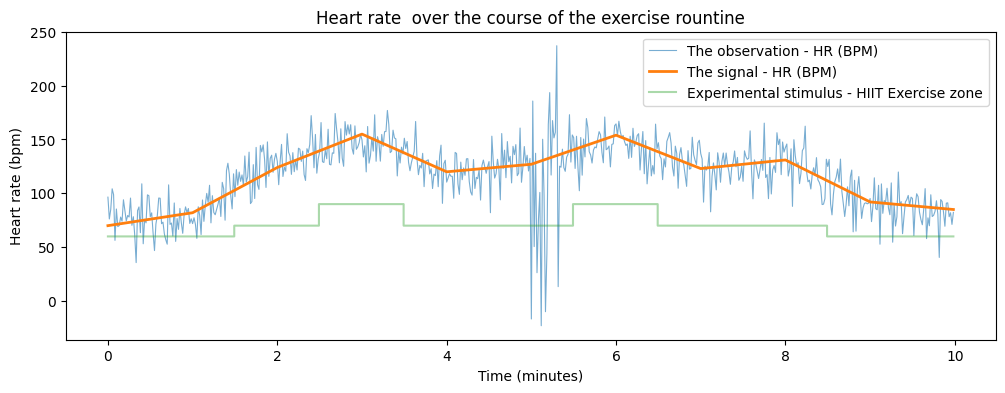

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add HIIT exercise zones
heart_rate['Exercise Zone']=np.array([0, 0, 1, 3, 1, 1, 3, 1, 1, 0])

# Interpolate data and add noise
heart_rate_sec = pd.DataFrame({
    "second": np.arange(0, 10*60),
    "hr_true": np.interp(np.arange(0, 10*60), heart_rate['Time (min)']*60, heart_rate['Heart rate (bpm)']),
    "zone": np.repeat(heart_rate['Exercise Zone'], 60)
})

heart_rate_sec.iloc[540:600,1] = np.linspace(heart_rate_sec.iloc[540,1], 85, 600 - 540)

zone = np.roll(heart_rate_sec['zone'], 570)
heart_rate_sec['zone']  = zone

np.random.seed(0)
noise = np.random.normal(0, 15, len(heart_rate_sec))

noise[300:320] += np.random.normal(0, 80, 320 - 300)

heart_rate_sec["hr_noisy"] = heart_rate_sec["hr_true"] + noise

#plot
plt.figure(figsize=(12,4))

plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["hr_noisy"],
         linewidth=0.8, alpha=0.6, label="The observation - HR (BPM)")

plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["hr_true"],
         linewidth=2, label="The signal - HR (BPM)")

plt.step(heart_rate_sec["second"]/60, heart_rate_sec["zone"]*10 + 60,
          where="mid", alpha=0.4, label="Experimental stimulus - HIIT Exercise zone")

plt.xlabel("Time (minutes)")
plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate  over the course of the exercise rountine")
plt.legend()
plt.show()

What trends do you see in the data?

What could be driving the noise in this setup?

Is there unaccounted sources of variance?

How can we isolate the signal of interest?

**TO REMOVE: I wanted students to think about measurement error here [i.e. why is there a massive spike in the data? fitbit slipped on the athletes wrist or something] but also unmeasured variable that could affect the signal beyond the exercise zone [i.e. elevation gain/loss] that could also be affecting measurements. I was also hoping that they might intuit averaging as a way to smooth out some noise.**


**Additionally, the burst is also to set up the example that different smoothing techniques are better suited for different noise [rolling mean vs median]. You can probably tune the noise I added to the heart rate data if you wanted to later filter it out using a lowpass filter.**

# Isolating the signal

The process of isolating a biologically meaningful signal from noise is called preprocessing. Their is an entire field of signal processing dedicated to getting the best signal to noise ratio out of observations. There are tons of methods and almost as many opinions on how to do this step correctly :p It can be a very overwhelming step to start on but we will touch on two classes of preprocessing techniques: averaging and spectral filtering (more to come on the spectral filtering later). One of the most straightforward methods to smooth the data is to use a rolling average / median

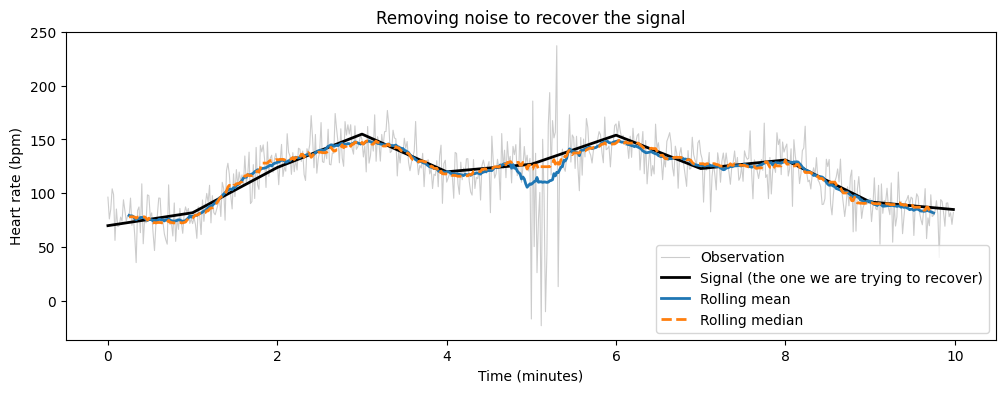

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rolling mean
heart_rate_sec["roll_mean"] = (heart_rate_sec["hr_noisy"]
                               .rolling(window=30, center=True).mean())

# Rolling median
heart_rate_sec["roll_median"] = (heart_rate_sec["hr_noisy"]
                                 .rolling(window=30, center=True).median())

plt.figure(figsize=(12,4))
plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["hr_noisy"],
         color="gray", alpha=0.4, linewidth=0.8, label="Observation")
plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["hr_true"], color="black",
         linewidth=2, label="Signal (the one we are trying to recover)")
plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["roll_mean"],
         linewidth=2, label="Rolling mean")
plt.plot(heart_rate_sec["second"]/60, heart_rate_sec["roll_median"],
         linewidth=2, linestyle="--", label="Rolling median")
plt.xlabel("Time (minutes)")
plt.ylabel("Heart rate (bpm)")
plt.title("Removing noise to recover the signal")
plt.legend()
plt.show()

Which preprocessing method is doing a better job of cleaning the data? Any idea as to why?

How do you decide which preprocessing method is best if you don't know the ground truth (i.e. the signal)?

**TO REMOVE: Santiago I leave it up to you if you want to decribe different types of noise here. I don't think its neccesary but I'll leave the decision to you**